In [46]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from kneed import KneeLocator
from sklearn import metrics
from sklearn.cluster import KMeans

In [ ]:
data_file = Path('..') / 'data' / 'data_processed' / 'SUPERSTORE_MODELAGEM.csv'
df = pd.read_csv(data_file, sep=',')

In [48]:
df.head()

,ORDER_DATE,SHIP_DATE,SHIP_MODE,CUSTOMER_ID,SEGMENT,COUNTRY,CITY,STATE,REGION,PRODUCT_ID,CATEGORY,SUB_CATEGORY,PRODUCT_NAME,PROFIT,NET_SALES,PROFIT_SCALED,NET_SALES_SCALED
0,2019-01-03,2019-01-07,STANDARD CLASS,DP-13000,CONSUMER,USA,HOUSTON,TX,CENTRAL,OFF-PA-10000174,OFFICE SUPPLIES,PAPER,"MESSAGE BOOK, WIREBOUND, FOUR 5 1/2"" X 4"" FORM...",5.5512,26.3168,-0.115131,-0.279599
1,2019-01-04,2019-01-08,STANDARD CLASS,PO-19195,HOME OFFICE,USA,NAPERVILLE,IL,CENTRAL,OFF-LA-10003223,OFFICE SUPPLIES,LABELS,AVERY 508,4.2717,28.2816,-0.120738,-0.279036
2,2019-01-05,2019-01-12,STANDARD CLASS,MB-18085,CONSUMER,USA,PHILADELPHIA,PA,EAST,OFF-AR-10003478,OFFICE SUPPLIES,ART,AVERY HI-LITER EVERBOLD PEN STYLE FLUORESCENT ...,4.8840,46.8864,-0.118055,-0.273708
3,2019-01-06,2019-01-07,FIRST CLASS,JO-15145,CORPORATE,USA,ATHENS,GA,SOUTH,OFF-AR-10002399,OFFICE SUPPLIES,ART,"DIXON PRANG WATERCOLOR PENCILS, 10-COLOR SET W...",5.2398,38.3400,-0.116495,-0.276156
4,2019-01-06,2019-01-08,SECOND CLASS,LS-17230,CONSUMER,USA,LOS ANGELES,CA,WEST,OFF-PA-10002005,OFFICE SUPPLIES,PAPER,XEROX 225,9.3312,58.3200,-0.098564,-0.270433


In [49]:
df_clustering = df[['ORDER_DATE', 'SHIP_MODE', 'CUSTOMER_ID', 'SEGMENT', 'CATEGORY', 'REGION', 'NET_SALES', 'PROFIT', 'NET_SALES_SCALED', 'PROFIT_SCALED']].copy()
df_clustering = df_clustering.reset_index(drop=True)

df_clustering = df_clustering.groupby('CUSTOMER_ID', as_index=False).agg({
    'ORDER_DATE': 'first',
    'SHIP_MODE': 'first',
    'CATEGORY': 'first',
    'REGION': 'first',
    'SEGMENT': 'first',
    'NET_SALES': 'sum',
    'PROFIT': 'sum',
    'NET_SALES_SCALED': 'sum',
    'PROFIT_SCALED': 'sum'
})

X_scaled = df_clustering.drop(columns=['CUSTOMER_ID', 'NET_SALES', 'PROFIT'])
X_scaled['ORDER_DATE'] = pd.to_datetime(df_clustering['ORDER_DATE'], errors='coerce').dt.year

In [50]:
df_clustering.head()

,CUSTOMER_ID,ORDER_DATE,SHIP_MODE,CATEGORY,REGION,SEGMENT,NET_SALES,PROFIT,NET_SALES_SCALED,PROFIT_SCALED
0,AA-10315,2019-03-31,STANDARD CLASS,OFFICE SUPPLIES,WEST,CONSUMER,204.7000,28.8658,-0.802781,-0.291871
1,AA-10375,2019-04-21,STANDARD CLASS,OFFICE SUPPLIES,WEST,CONSUMER,1171.1996,91.3899,-1.674506,-0.575691
2,AA-10480,2019-05-04,SAME DAY,FURNITURE,EAST,CONSUMER,357.4148,63.0594,-0.759041,-0.142015
3,AA-10645,2019-12-01,FIRST CLASS,FURNITURE,EAST,CONSUMER,291.2400,38.4204,-0.777994,-0.249997
4,AB-10015,2019-02-18,STANDARD CLASS,OFFICE SUPPLIES,CENTRAL,CONSUMER,59.1680,2.9553,-0.557327,-0.265966


In [51]:
cols_one_hot = ['SHIP_MODE', 'SEGMENT', 'REGION', 'CATEGORY', 'ORDER_DATE']

for col in cols_one_hot:
    print(df_clustering[col].value_counts(), '\n')

SHIP_MODE
STANDARD CLASS    445
SECOND CLASS      162
FIRST CLASS       119
SAME DAY           44
Name: count, dtype: int64 

SEGMENT
CONSUMER       395
CORPORATE      229
HOME OFFICE    146
Name: count, dtype: int64 

REGION
WEST       284
EAST       210
CENTRAL    141
SOUTH      135
Name: count, dtype: int64 

CATEGORY
OFFICE SUPPLIES    512
FURNITURE          142
TECHNOLOGY         116
Name: count, dtype: int64 

ORDER_DATE
2019-11-01    6
2019-09-30    5
2019-04-05    5
2019-09-23    4
2019-11-21    4
             ..
2020-05-06    1
2019-10-25    1
2021-06-30    1
2020-11-09    1
2020-01-17    1
Name: count, Length: 515, dtype: int64 



In [52]:
X_scaled = pd.get_dummies(
    X_scaled,
    columns=cols_one_hot)

In [ ]:
# Range de clusters
k_range = range(2, 8)

results = {
    'k': [],
    'inertia': [],
    'silhouette': [],
    'calinski_harabasz': [],
    'davies_bouldin': [],
}

# Loop
for k in k_range:
    model = KMeans(n_clusters=k, 
        n_init=10,
        random_state=0,
        max_iter=200
    )
    labels = model.fit_predict(X_scaled)

    results['k'].append(k)
    results['inertia'].append(model.inertia_)
    results['silhouette'].append(
        metrics.silhouette_score(X_scaled, labels)
    )
    results['calinski_harabasz'].append(
        metrics.calinski_harabasz_score(X_scaled, labels)
    )
    results['davies_bouldin'].append(
        metrics.davies_bouldin_score(X_scaled, labels)
    )


df_metrics = pd.DataFrame(results).set_index('k')

knee = KneeLocator(
    x=df_metrics.index,
    y=df_metrics['inertia'],
    curve='convex',
    direction='decreasing'
)

k_optimal = knee.knee
if k_optimal is None:
    print('Elbow não encontrado')
    
k_sil = df_metrics['silhouette'].idxmax()
k_ch  = df_metrics['calinski_harabasz'].idxmax()
k_db  = df_metrics['davies_bouldin'].idxmin()

k_summary = pd.DataFrame({
    'method': ['silhouette', 'calinski_harabasz', 'davies_bouldin', 'elbow'],
    'k': [k_sil, k_ch, k_db, k_optimal]
})

k_summary

Elbow não encontrado


,method,k
0,silhouette,3.0
1,calinski_harabasz,2.0
2,davies_bouldin,7.0
3,elbow,NaN


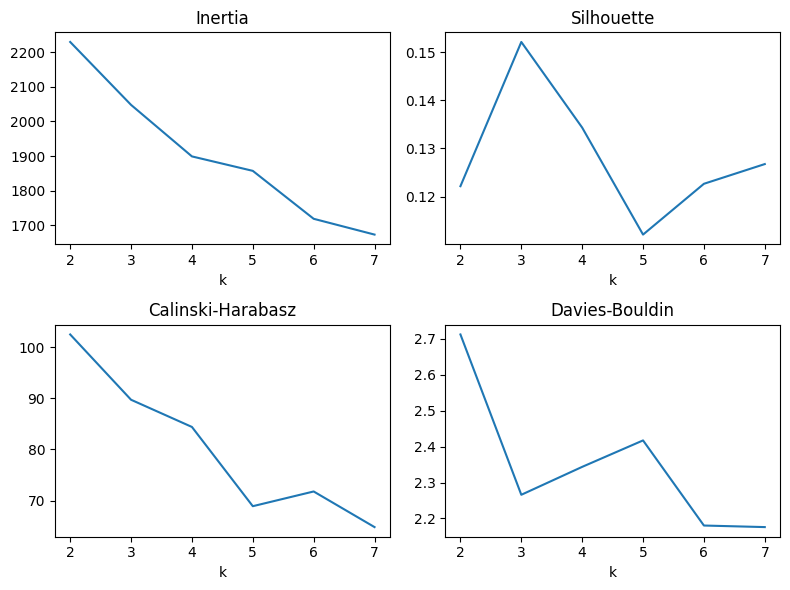

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

df_metrics['inertia'].plot(ax=axes[0, 0], title='Inertia')

if k_optimal is not None:
    axes[0, 0].axvline(k_optimal, linestyle='--')

df_metrics['silhouette'].plot(ax=axes[0, 1], title='Silhouette')
df_metrics['calinski_harabasz'].plot(ax=axes[1, 0], title='Calinski-Harabasz')
df_metrics['davies_bouldin'].plot(ax=axes[1, 1], title='Davies-Bouldin')

plt.tight_layout()
plt.show()

In [55]:
kmeans_publico = KMeans(n_clusters=3, 
        n_init=10,
        random_state=0
    )
kmeans_publico.fit(X_scaled)
labels = kmeans_publico.labels_

df_clustering['CLUSTER'] = labels


In [56]:
centroids = pd.DataFrame(
    kmeans_publico.cluster_centers_,
    columns=X_scaled.columns
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

display(centroids.round(2))

,NET_SALES_SCALED,PROFIT_SCALED,SHIP_MODE_FIRST CLASS,SHIP_MODE_SAME DAY,SHIP_MODE_SECOND CLASS,SHIP_MODE_STANDARD CLASS,SEGMENT_CONSUMER,SEGMENT_CORPORATE,SEGMENT_HOME OFFICE,REGION_CENTRAL,REGION_EAST,REGION_SOUTH,REGION_WEST,CATEGORY_FURNITURE,CATEGORY_OFFICE SUPPLIES,CATEGORY_TECHNOLOGY,ORDER_DATE_2019,ORDER_DATE_2020,ORDER_DATE_2021,ORDER_DATE_2022
0,-0.80,-0.26,0.14,0.07,0.25,0.55,1.0,0.0,-0.0,0.16,0.29,0.18,0.36,0.18,0.65,0.18,0.52,0.25,0.15,0.07
1,-0.81,-0.27,0.19,0.03,0.19,0.58,0.0,1.0,-0.0,0.20,0.26,0.20,0.34,0.19,0.68,0.13,0.51,0.28,0.16,0.05
2,-0.74,-0.24,0.14,0.05,0.14,0.66,0.0,0.0,1.0,0.21,0.25,0.11,0.42,0.19,0.70,0.11,0.46,0.29,0.18,0.08


In [57]:
resumo_clusters = (
    df_clustering
    .groupby('CLUSTER')
    .agg(
        qtd_clientes=('CUSTOMER_ID', 'count'),
        media_net_sales=('NET_SALES', 'mean'),
        media_profit=('PROFIT', 'mean')
    )
    .reset_index()
    .sort_values('CLUSTER')
    .reset_index(drop=True)
)

resumo_clusters.columns = [col.upper() for col in resumo_clusters.columns]

display(resumo_clusters.round(2))

,CLUSTER,QTD_CLIENTES,MEDIA_NET_SALES,MEDIA_PROFIT
0,0,395,868.46,56.02
1,1,229,889.33,56.64
2,2,146,722.67,49.42


In [58]:
px.scatter(
    df_clustering,
    x='PROFIT',
    y='NET_SALES',
    color=df_clustering['CLUSTER'].astype(str)
)

In [59]:
px.histogram(
    df_clustering,
    x='ORDER_DATE',
    y='PROFIT',
    nbins=(2022-2019)*12,
    color=df_clustering['CLUSTER'].astype(str)
)

In [60]:
px.histogram(
    df_clustering,
    x='ORDER_DATE',
    y='NET_SALES',
    nbins=(2022-2019)*12,
    color=df_clustering['CLUSTER'].astype(str)
)